In [ ]:
%pip install matplotlib seaborn

In [ ]:
!pip install statsmodels

In [ ]:
!pip install scikit-learn

## Opis procesu zbierania danych

Z wykorzystaniem biblioteki **BeautifulSoup** oraz parsowania ukrytych obiektów JSON zebrano linki do poszczególnych ofert z podstron wyszukiwania. 

Z każdego zebranego linku pobrano parametry takie jak: cena, metraż, liczba pokoi, klasa energetyczna, lokalizacja oraz treść opisu. Z opisu, za pomocą analizy słów kluczowych, wyekstrahowano binarne dane informujące o udogodnieniach (winda, klimatyzacja, bliskość morza, stan po remoncie).

Z powodu blokady strony i wyświetlania jedynie 300 stron ze strony głównej, konieczne było scrapowanie stron z wykorzystaniem filtrow cenowych.
Dzięki temu uzyskano dostęp do ok. 105 000 ogłoszeń. Przez częste blokady strony, konieczne było uzycie wysokiego parametru time.sleep. Po ponad 30 godzinach scrapowania, ze względu na ograniczenia czasowe, zdecydowano o zaprzestaniu procesu. Zapisano więc finalnie prawie 36000 ogłoszeń. 
Ogłoszenia zapisywały sie do pliku csv losowo (to znaczy brane były losowo z różnych przedziałow cenowych). 

## Transformacje zmiennych
W poniższym pliku będzie można zaobserować, że ze względu na prawoskośność rozkładu cen zdecydowano się na zlogarytmizowanie zmiennej zależnej. Zmienna kategoryczna oznaczająca prowincję została zakodowana z wykorzystaniem średniej ceny dla danej prowincji. 20 włoskich regionów zostało zakodowanych jako zmienne binarne. 

**Diagnostyka modelu i proces powstawania modelu znajduje się poniżej:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib



sns.set_theme(style="whitegrid")

# Wczytuję dane i sprawdzam liczbę ogłoszeń
df_raw = pd.read_csv("data_real_assets.csv")
print(f"Liczba pobranych ogłoszeń (Surowe dane): {len(df_raw)}")

# Usuwanie brakow danych
df_clean = df_raw.dropna(subset=['Cena', 'Metraz', 'URL']).copy()

# Usuwanie duplikatów
df_clean = df_clean.drop_duplicates(subset=['URL'])

# filtruje po kategoriach z url
df_mieszkania = df_clean[df_clean['URL'].str.contains('/appartamenti/', case=False, na=False)].copy()

df_domy = df_clean[df_clean['URL'].str.contains('/ville-singole-e-a-schiera/', case=False, na=False)].copy()

print(f"Liczba mieszkań: {len(df_mieszkania)}")
print(f"Liczba domów: {len(df_domy)}")



Liczba pobranych ogłoszeń (Surowe dane): 35742
Liczba mieszkań: 17834
Liczba domów: 8890


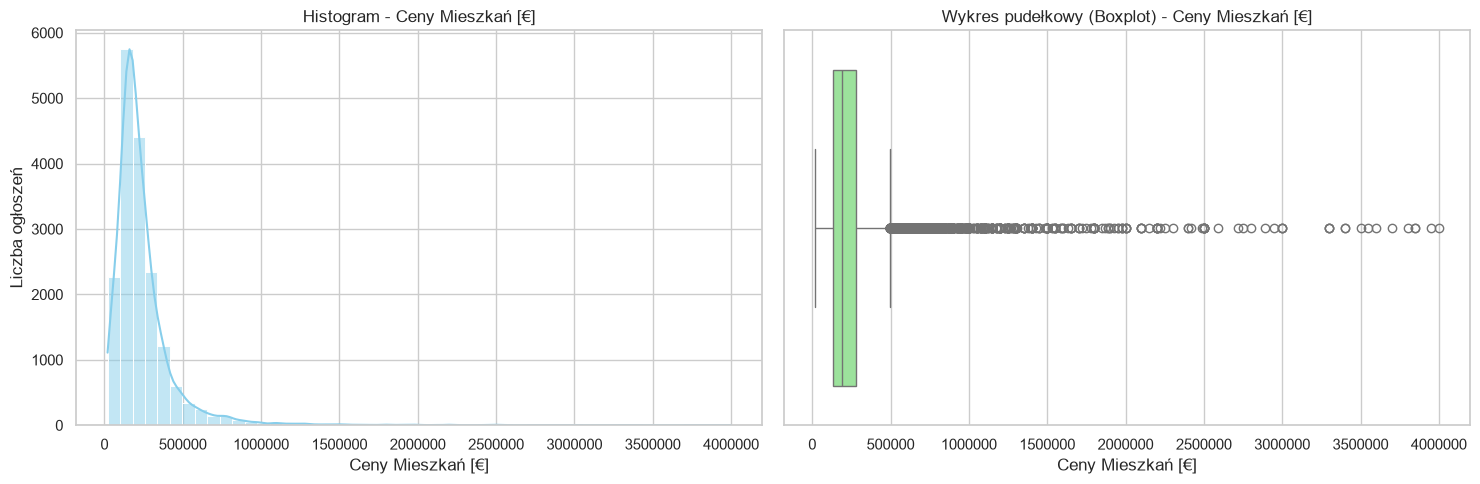

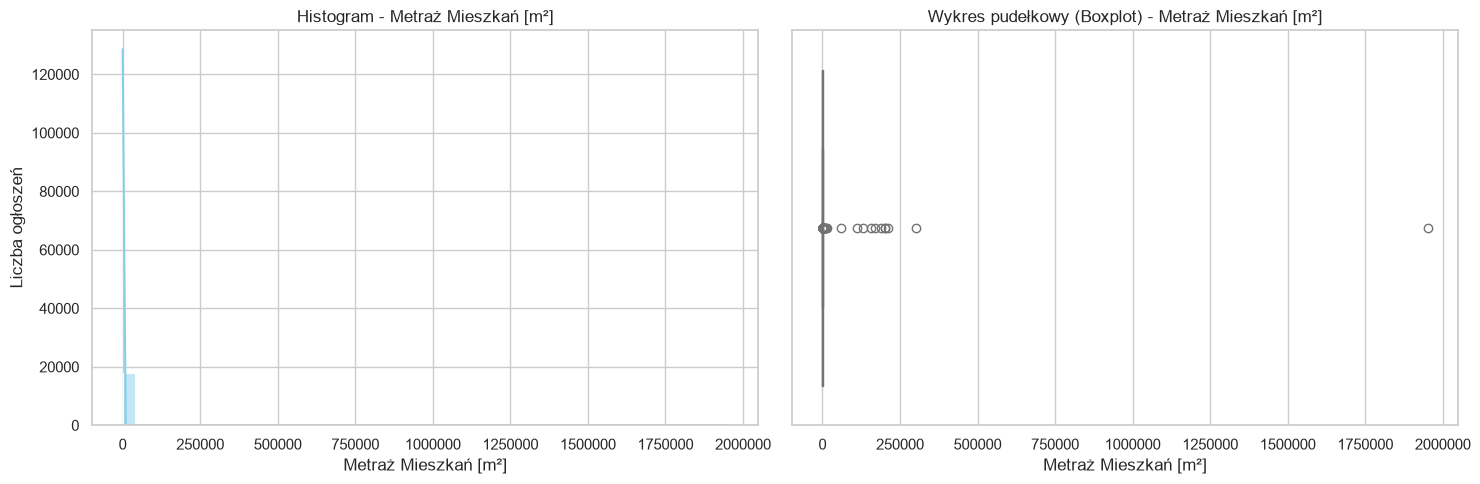

In [2]:
def plot_distribution(df, column, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
   
    sns.histplot(df[column], bins=50, kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f'Histogram - {title}')
    axes[0].set_xlabel(title) 
    axes[0].set_ylabel('Liczba ogłoszeń')
    
    axes[0].ticklabel_format(style='plain', axis='x') 
    
   
    sns.boxplot(x=df[column], ax=axes[1], color="lightgreen")
    axes[1].set_title(f'Wykres pudełkowy (Boxplot) - {title}')
    axes[1].set_xlabel(title) # Używamy tytułu z jednostką
    # Wyłączenie notacji naukowej (np. 1e6) dla czytelności
    axes[1].ticklabel_format(style='plain', axis='x') 
    
    plt.tight_layout()
    plt.show()



plot_distribution(df_mieszkania, 'Cena', 'Ceny Mieszkań [€]')

plot_distribution(df_mieszkania, 'Metraz', 'Metraż Mieszkań [m²]')

Obserwuje się bardzo dziwne anomalie związane z metrazem.

In [3]:
pd.set_option('display.max_columns', None)
# Aby zapobiec ucinaniu długich linków URL w tabeli:
pd.set_option('display.max_colwidth', None)



anomalie_mieszkania = df_mieszkania[df_mieszkania['Metraz'] > 300].sort_values(by='Metraz', ascending=False)

display(anomalie_mieszkania)


anomalie_domy = df_domy[df_domy['Metraz'] > 1000].sort_values(by='Metraz', ascending=False)
display(anomalie_domy)

,Tytul,Prowincja,Cena,Metraz,Liczba_Pokoi,Typ_Dom,Klasa_Energetyczna,URL,Blisko_Morza,Po_Remoncie,Winda,Klimatyzacja,Dlugosc_Opisu
14563,Palazzo / Stabile di 1951800 m² con più di 5 local,Castelnuovo di Val di Cecina (PI),700000,1951800,6,0,Esente,https://www.subito.it/appartamenti/palazzo-stabile-di-1951800-m²-con-piu-di-5-local-pisa-645385769.htm,0,0,0,0,643
12295,Agriturismo scuderia tenuta Giano vetusto,Giano Vetusto (CE),900000,300000,10,0,In attesa di certificazione,https://www.subito.it/appartamenti/agriturismo-scuderia-tenuta-giano-vetusto-caserta-614982988.htm,0,0,0,0,496
29095,3Vani Garage e Terrazzo Nuova Costruzione Zona Mar,Catania (CT),210000,210000,2,0,-,https://www.subito.it/appartamenti/3vani-garage-e-terrazzo-nuova-costruzione-zona-mar-catania-651315155.htm,0,0,1,0,1070
10884,Appartamento Piancastagnaio [A4351618],Piancastagnaio (SI),348750,200000,1,0,Non classificabile,https://www.subito.it/appartamenti/appartamento-piancastagnaio-a4351618-siena-648808906.htm,0,0,0,0,1985
21650,Appartamento Gissi [A4334667],Gissi (CH),23040,200000,10,0,Non classificabile,https://www.subito.it/appartamenti/appartamento-gissi-a4334667-chieti-650504119.htm,0,0,0,0,1742
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31884,4 LOCALI A ARZIGNANO,Arzignano (VI),450000,305,4,0,B,https://www.subito.it/appartamenti/4-locali-a-arzignano-vicenza-642816567.htm,0,0,0,0,1984
14302,Appartamento Brindisi [MQ327VRG],Brindisi (BR),250000,305,6,0,G,https://www.subito.it/appartamenti/appartamento-brindisi-mq327vrg-brindisi-638656774.htm,0,0,0,0,899
15444,MULTILOCALE A MONTALTO DI CASTRO,Montalto di Castro (VT),490000,305,9,0,G,https://www.subito.it/appartamenti/multilocale-a-montalto-di-castro-viterbo-640620070.htm,1,1,0,0,1985
28,Appartamento di 304 m² con 5 locali e box auto a B,Bergamo (BG),2500000,304,5,0,B,https://www.subito.it/appartamenti/appartamento-di-304-m²-con-5-locali-e-box-auto-a-b-bergamo-635615583.htm,0,0,0,0,1868


,Tytul,Prowincja,Cena,Metraz,Liczba_Pokoi,Typ_Dom,Klasa_Energetyczna,URL,Blisko_Morza,Po_Remoncie,Winda,Klimatyzacja,Dlugosc_Opisu
18951,Villa indipendente in corso d'opera,Salice Salentino (LE),145000,33137701,0,1,Brak,https://www.subito.it/ville-singole-e-a-schiera/villa-indipendente-in-corso-d-opera-lecce-644755739.htm,0,0,0,0,533
34612,Villetta a schiera di 129013 m² con 5 locali e box,Bucine (AR),175000,129013,5,1,G,https://www.subito.it/ville-singole-e-a-schiera/villetta-a-schiera-di-129013-m²-con-5-locali-e-box-arezzo-648718939.htm,0,0,0,0,603
10713,Ramiseto-villa unifamiliare,Ventasso (RE),125000,125000,0,1,Brak,https://www.subito.it/ville-singole-e-a-schiera/ramiseto-villa-unifamiliare-reggio-emilia-643398759.htm,0,0,0,0,218
9072,Villetta all'interno di un' azienda agricola,Catanzaro (CZ),295000,110000,5,1,-,https://www.subito.it/ville-singole-e-a-schiera/villetta-all-interno-di-un-azienda-agricola-catanzaro-650356631.htm,0,0,0,0,389
17848,CASA DI CORTE A OSTUNI,Ostuni (BR),48000,80000,1,1,Esente,https://www.subito.it/ville-singole-e-a-schiera/casa-di-corte-a-ostuni-brindisi-649592161.htm,0,0,0,0,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33158,Villa di 1070 m² con più di 5 locali a Carmignano,Carmignano (PO),2000000,1070,6,1,G,https://www.subito.it/ville-singole-e-a-schiera/villa-di-1070-m²-con-piu-di-5-locali-a-carmignano-prato-645116157.htm,0,0,0,0,1247
34737,Villa - Montenero di Bisaccia,Montenero di Bisaccia (CB),950000,1050,10,1,C,https://www.subito.it/ville-singole-e-a-schiera/villa-montenero-di-bisaccia-campobasso-622093932.htm,1,0,0,0,1294
22301,Assemini. Lotto edificabile di 1041 mq Zona B,Assemini (CA),380000,1041,6,1,In attesa di certificazione,https://www.subito.it/ville-singole-e-a-schiera/assemini-lotto-edificabile-di-1041-mq-zona-b-cagliari-642585670.htm,0,0,0,0,572
5191,CASA INDIPENDENTE A AREZZO,Arezzo (AR),430000,1035,10,1,Esente,https://www.subito.it/ville-singole-e-a-schiera/casa-indipendente-a-arezzo-arezzo-643320319.htm,0,0,0,0,743


Widać, że problem nie leży w błędnym scrapowaniu, bądź błędnej filtracji a są to błędy w samych ogłoszeniach - np. podawana jest cena w polu metraz, badz ogromne tereny są w kategorii "apartementy". Postanawiam w takim razie usunąć te wartości odstające (które mogą mieć negatywny wpływ na działanie modelu) na podstawie rozstępu międzykwartylowego. Modyfikuje jednak mnożnik z 1,5 na 3, ponieważ przy klasycznym podejsciu odrzucanych bylo za duzo mieszkan, ktorych ceny są standardowane (np. na Rzym). 

In [4]:
def usun_outliery_iqr(df, kolumna, min_wartosc, mnoznik=3.0):
    Q1 = df[kolumna].quantile(0.25)
    Q3 = df[kolumna].quantile(0.75)
    IQR = Q3 - Q1
   
    dolna_granica = max(min_wartosc, Q1 - mnoznik * IQR)
    gorna_granica = Q3 + mnoznik * IQR
    
    df_przefiltrowane = df[(df[kolumna] >= dolna_granica) & (df[kolumna] <= gorna_granica)]
    
    odrzucone = len(df) - len(df_przefiltrowane)
    print(f"[{kolumna}] Odrzucono {odrzucone} ogłoszeń. Zostawiono zakres: ({dolna_granica:.0f} - {gorna_granica:.0f})")
    
    return df_przefiltrowane


df_mieszkania_czyste = usun_outliery_iqr(df_mieszkania, 'Metraz', min_wartosc=15)
df_mieszkania_czyste = usun_outliery_iqr(df_mieszkania_czyste, 'Cena', min_wartosc=15000)


df_domy_czyste = usun_outliery_iqr(df_domy, 'Metraz', min_wartosc=30)
df_domy_czyste = usun_outliery_iqr(df_domy_czyste, 'Cena', min_wartosc=20000)

[Metraz] Odrzucono 489 ogłoszeń. Zostawiono zakres: (15 - 295)
[Cena] Odrzucono 429 ogłoszeń. Zostawiono zakres: (15000 - 711000)
[Metraz] Odrzucono 259 ogłoszeń. Zostawiono zakres: (30 - 754)
[Cena] Odrzucono 221 ogłoszeń. Zostawiono zakres: (20000 - 1145000)


Zakresy wydają się sensowne. Sprawdzam teraz statystyki opisowe zmiennych:

In [5]:
statystyki_mieszkania = df_mieszkania_czyste[['Cena', 'Metraz', 'Liczba_Pokoi', 'Dlugosc_Opisu']].describe().round(2)
display(statystyki_mieszkania)
statystyki_domy = df_domy_czyste[['Cena', 'Metraz', 'Liczba_Pokoi', 'Dlugosc_Opisu']].describe().round(2)
display(statystyki_domy)

,Cena,Metraz,Liczba_Pokoi,Dlugosc_Opisu
count,16916.00,16916.00,16916.0,16916.00
mean,213661.39,104.08,3.5,1135.17
std,122582.03,42.31,1.6,535.18
min,20000.00,15.00,0.0,18.00
25%,135000.00,75.00,3.0,727.00
50%,185000.00,99.00,3.0,1094.00
75%,269000.00,125.00,4.0,1576.00
max,710000.00,295.00,10.0,2008.00


,Cena,Metraz,Liczba_Pokoi,Dlugosc_Opisu
count,8410.00,8410.00,8410.00,8410.00
mean,305295.82,215.59,5.22,1183.45
std,208199.75,119.70,2.45,549.34
min,20000.00,30.00,0.00,18.00
25%,160000.00,130.00,4.00,762.00
50%,250000.00,187.00,5.00,1152.00
75%,393937.50,270.00,6.00,1674.00
max,1140000.00,750.00,10.00,2009.00


Statystyki opisowe wyglądają dobrze. Jedyną alarmującą rzeczą jest minimalna wartość 0 w liczbie pokoi - jest to prawdopodobnie błąd, albo brak danych. Usuwam takie wiersze

In [6]:
df_mieszkania_czyste = df_mieszkania_czyste[df_mieszkania_czyste['Liczba_Pokoi'] > 0]
df_domy_czyste = df_domy_czyste[df_domy_czyste['Liczba_Pokoi'] > 0]

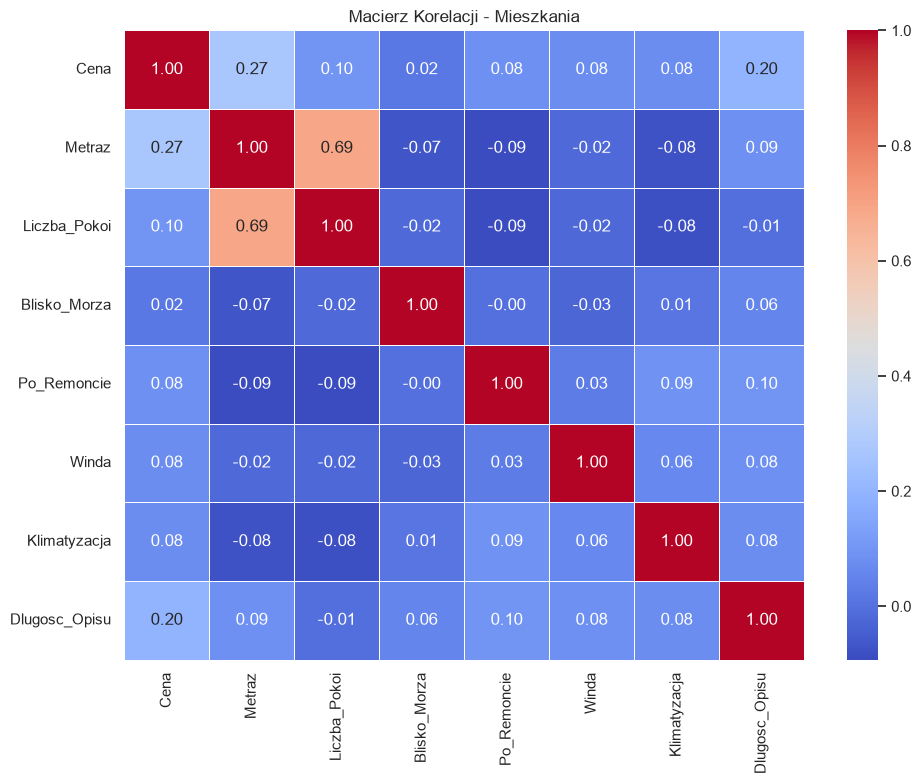

In [7]:
kolumny_numeryczne = ['Cena', 'Metraz', 'Liczba_Pokoi', 'Blisko_Morza', 'Po_Remoncie', 'Winda', 'Klimatyzacja', 'Dlugosc_Opisu']


korelacje_mieszkania = df_mieszkania_czyste[kolumny_numeryczne].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(korelacje_mieszkania, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Macierz Korelacji - Mieszkania')
plt.tight_layout()
plt.show()

Korelacja metrażu z ceną jest umiarkowana, ale można byłoby spodziewać się wyższej. Istnieje wysokie prawdopodobieństwo, że przyczyną może być lokalizacja - badamy mieszkania z całego terenu Włoch i ceny mogą być bardzo zrónicowane. To samo tyczy się zmiennych zero-jedynkowych np. Blisko Morza - mieszkania na południu Włoch nawet pomimo tego, że są blisko morza będą znacznie tańsze niż w Rzymie, czy w Alpach. Należy zwrócić także uwagę na korelację 0.2 między długością opisu a ceną i na współliniowość (spodziewaną) pomiędzy metrażem a liczbą pokoi. 

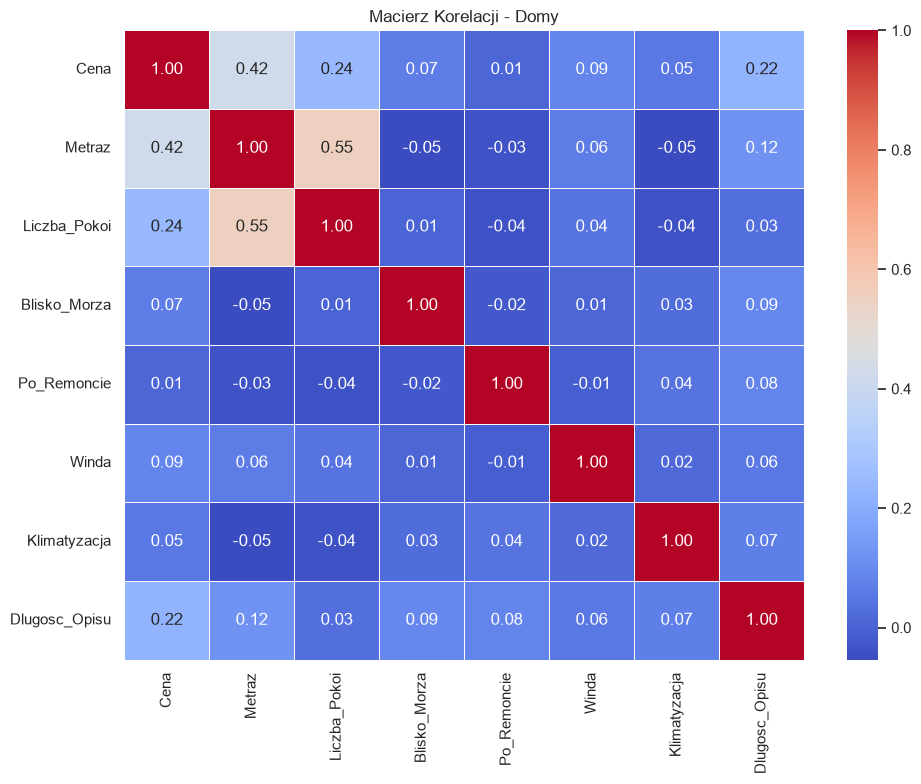

In [8]:

korelacje_domy = df_domy_czyste[kolumny_numeryczne].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(korelacje_domy, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Macierz Korelacji - Domy')
plt.tight_layout()
plt.show()

W przypadku domów korelacja między ceną a metrażem jest już trochę wyższa (0.42); podobnie w przypadku liczby pokoi (0.24).

Sprawdzanie rozkładu zmiennej zależnej:

Współczynnik skośności ceny przed transformacją: 1.23


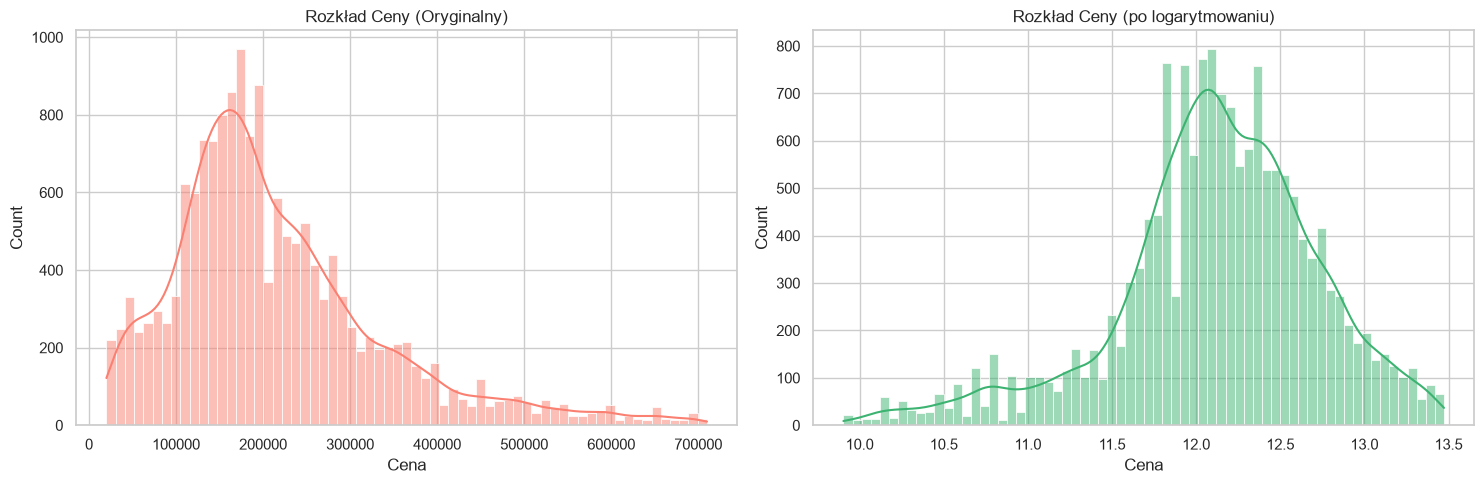

In [9]:
skew = df_mieszkania_czyste['Cena'].skew()
print(f"Współczynnik skośności ceny przed transformacją: {skew:.2f}")

# 2. Wizualizacja przed i po logarytmowaniu
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Oryginalna cena
sns.histplot(df_mieszkania_czyste['Cena'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Rozkład Ceny (Oryginalny)')

# Cena po logarytmowaniu
cena_log = np.log1p(df_mieszkania_czyste['Cena'])
sns.histplot(cena_log, kde=True, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Rozkład Ceny (po logarytmowaniu)')

plt.tight_layout()
plt.show()



Wstępna analiza rozkładu zmiennej zależnej (Cena) wykazała istotną prawostronną skośność (1.23)Zastosowano transformację logarytmiczną log(1+x), która pozwoliła na pewne zredukowanie skośności i uzyskanie rozkładu bardziej zbliżonego do normalnego.

Współczynnik skośności ceny przed transformacją: 1.28


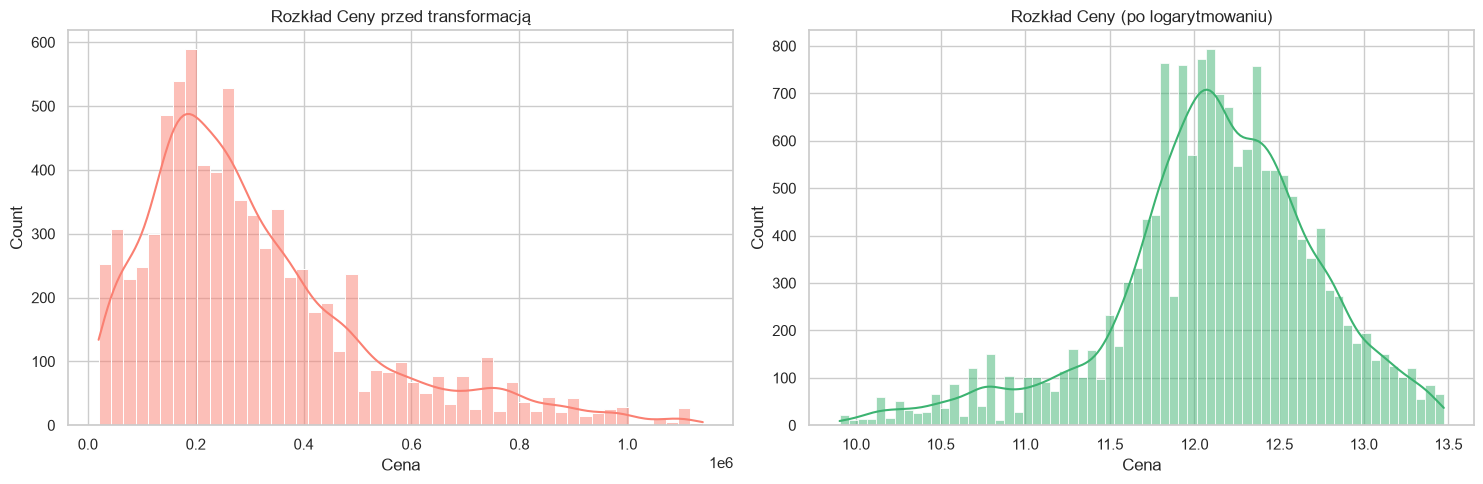

In [10]:
skew_domy = df_domy_czyste['Cena'].skew()
print(f"Współczynnik skośności ceny przed transformacją: {skew_domy:.2f}")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(df_domy_czyste['Cena'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Rozkład Ceny przed transformacją')


cena_log = np.log1p(df_mieszkania_czyste['Cena'])
sns.histplot(cena_log, kde=True, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Rozkład Ceny (po logarytmowaniu)')

plt.tight_layout()
plt.show()

Chcę teraz zająć się moją zmienną tekstową Prowincja.

In [11]:
liczba_prowincji = df_mieszkania_czyste['Prowincja'].nunique()
print(f"Liczba unikalnych prowincji w zbiorze mieszkań: {liczba_prowincji}")

Liczba unikalnych prowincji w zbiorze mieszkań: 2703


Informacje są wymieszane. Wyciągam więc tylko kod prowincji, który zawsze znajduje się w nawiasie.

In [26]:
# Wyciągamy kod z nawiasu
df_mieszkania_czyste['Kod_Prowincji'] = df_mieszkania_czyste['Prowincja'].str.extract(r'\(([^)]+)\)')

# Jeśli gdzieś nie było nawiasu - "Unknown"
df_mieszkania_czyste['Kod_Prowincji'] = df_mieszkania_czyste['Kod_Prowincji'].fillna('Unknown')

print(f"Liczba unikalnych kodów prowincji: {df_mieszkania_czyste['Kod_Prowincji'].nunique()}")

df_domy_czyste['Kod_Prowincji'] = df_domy_czyste['Prowincja'].str.extract(r'\(([^)]+)\)')

# Jeśli gdzieś nie było nawiasu - "Unknown"
df_domy_czyste['Kod_Prowincji'] = df_domy_czyste['Kod_Prowincji'].fillna('Unknown')

print(f"Liczba unikalnych kodów prowincji dla domów: {df_domy_czyste['Kod_Prowincji'].nunique()}")

Liczba unikalnych kodów prowincji: 110
Liczba unikalnych kodów prowincji dla domów: 110


Teraz wszystko się zgadza - prowincji we Włoszech rzeczywiście jest 110. Tworzę nową zmienną, która oblicza mi średnią wartość ceny na m2 dla każdej prowincji. 

In [ ]:

mean_price_map = df_mieszkania_czyste.groupby('Kod_Prowincji')['Cena'].mean()


df_mieszkania_czyste['Prowincja_Encoded'] = df_mieszkania_czyste['Kod_Prowincji'].map(mean_price_map)

mean_price_map_domy = df_domy_czyste.groupby('Kod_Prowincji')['Cena'].mean()


df_domy_czyste['Prowincja_Encoded'] = df_domy_czyste['Kod_Prowincji'].map(mean_price_map)



In [28]:

prowincje_check = df_mieszkania_czyste.groupby('Kod_Prowincji').agg(
    Srednia_Cena=('Cena', 'mean'),
    Liczba_Ogloszen=('Cena', 'count')
).sort_values(by='Srednia_Cena', ascending=False)


print("20 najdroższych prowincji")
display(prowincje_check.head(20))

print("20 najtańszych prowincji")
display(prowincje_check.tail(20))

prowincje_check_domy = df_domy_czyste.groupby('Kod_Prowincji').agg(
    Srednia_Cena=('Cena', 'mean'),
    Liczba_Ogloszen=('Cena', 'count')
).sort_values(by='Srednia_Cena', ascending=False)


print("20 najdroższych prowincji")
display(prowincje_check_domy.head(20))

print("20 najtańszych prowincji")
display(prowincje_check_domy.tail(20))

20 najdroższych prowincji


,Srednia_Cena,Liczba_Ogloszen
Kod_Prowincji,,
BZ,427505.107843,102
FI,301465.205776,277
MI,291616.675876,1484
RN,288431.034483,174
TN,280880.434783,138
VR,278899.581590,239
SV,274514.285714,140
BO,273296.391753,388
RA,272730.065359,153


20 najtańszych prowincji


,Srednia_Cena,Liczba_Ogloszen
Kod_Prowincji,,
CS,131551.817391,115
PV,127457.247191,89
TR,126699.584906,53
BN,125282.608696,46
AL,121110.033898,59
KR,120666.666667,6
CI,120243.703704,54
RO,119235.294118,34
TA,119046.242775,173


20 najdroższych prowincji


,Srednia_Cena,Liczba_Ogloszen
Kod_Prowincji,,
BZ,772777.777778,9
FI,522116.883117,77
LI,516216.176471,51
MS,496150.000000,20
OT,488946.202532,79
MB,472265.533333,60
RN,469035.087719,57
IM,461339.622642,53
GR,452195.351351,37


20 najtańszych prowincji


,Srednia_Cena,Liczba_Ogloszen
Kod_Prowincji,,
OR,207737.938144,97
MT,207666.666667,6
IS,206607.000000,8
TA,206021.126761,71
RG,203649.757143,140
AV,202863.414634,41
OG,201500.000000,14
CT,199653.883495,412
BI,197813.043478,23


In [ ]:

province_to_region = {
    'AQ': 'Abruzzo', 'CH': 'Abruzzo', 'PE': 'Abruzzo', 'TE': 'Abruzzo',
    'MT': 'Basilicata', 'PZ': 'Basilicata',
    'CZ': 'Calabria', 'CS': 'Calabria', 'KR': 'Calabria', 'RC': 'Calabria', 'VV': 'Calabria',
    'AV': 'Campania', 'BN': 'Campania', 'CE': 'Campania', 'NA': 'Campania', 'SA': 'Campania',
    'BO': 'Emilia-Romagna', 'FE': 'Emilia-Romagna', 'FC': 'Emilia-Romagna', 'MO': 'Emilia-Romagna', 'PR': 'Emilia-Romagna', 'PC': 'Emilia-Romagna', 'RA': 'Emilia-Romagna', 'RE': 'Emilia-Romagna', 'RN': 'Emilia-Romagna',
    'GO': 'Friuli-Venezia Giulia', 'PN': 'Friuli-Venezia Giulia', 'TS': 'Friuli-Venezia Giulia', 'UD': 'Friuli-Venezia Giulia',
    'FR': 'Lazio', 'LT': 'Lazio', 'RI': 'Lazio', 'RM': 'Lazio', 'VT': 'Lazio',
    'GE': 'Liguria', 'IM': 'Liguria', 'SP': 'Liguria', 'SV': 'Liguria',
    'BG': 'Lombardia', 'BS': 'Lombardia', 'CO': 'Lombardia', 'CR': 'Lombardia', 'LC': 'Lombardia', 'LO': 'Lombardia', 'MB': 'Lombardia', 'MI': 'Lombardia', 'MN': 'Lombardia', 'PV': 'Lombardia', 'SO': 'Lombardia', 'VA': 'Lombardia',
    'AN': 'Marche', 'AP': 'Marche', 'FM': 'Marche', 'MC': 'Marche', 'PU': 'Marche',
    'CB': 'Molise', 'IS': 'Molise',
    'AL': 'Piemonte', 'AT': 'Piemonte', 'BI': 'Piemonte', 'CN': 'Piemonte', 'NO': 'Piemonte', 'TO': 'Piemonte', 'VB': 'Piemonte', 'VC': 'Piemonte',
    'BA': 'Puglia', 'BT': 'Puglia', 'BR': 'Puglia', 'FG': 'Puglia', 'LE': 'Puglia', 'TA': 'Puglia',
    'CA': 'Sardegna', 'NU': 'Sardegna', 'OR': 'Sardegna', 'SS': 'Sardegna', 'SU': 'Sardegna', 'CI': 'Sardegna', 'VS': 'Sardegna', 'OG': 'Sardegna', 'OT': 'Sardegna',
    'AG': 'Sicilia', 'CL': 'Sicilia', 'CT': 'Sicilia', 'EN': 'Sicilia', 'ME': 'Sicilia', 'PA': 'Sicilia', 'RG': 'Sicilia', 'SR': 'Sicilia', 'TP': 'Sicilia',
    'AR': 'Toscana', 'FI': 'Toscana', 'GR': 'Toscana', 'LI': 'Toscana', 'LU': 'Toscana', 'MS': 'Toscana', 'PI': 'Toscana', 'PT': 'Toscana', 'PO': 'Toscana', 'SI': 'Toscana',
    'BZ': 'Trentino-Alto Adige', 'TN': 'Trentino-Alto Adige',
    'PG': 'Umbria', 'TR': 'Umbria',
    'AO': 'Valle d\'Aosta',
    'BL': 'Veneto', 'PD': 'Veneto', 'RO': 'Veneto', 'TV': 'Veneto', 'VE': 'Veneto', 'VR': 'Veneto', 'VI': 'Veneto'
}



df_domy_czyste['Region'] = df_domy_czyste['Kod_Prowincji'].map(province_to_region)


df_domy_czyste['Region'] = df_domy_czyste['Region'].fillna('Inne')


df_domy_encoded = pd.get_dummies(df_domy_czyste, columns=['Region'], drop_first=True, dtype=int)

df_mieszkania_czyste['Region'] = df_mieszkania_czyste['Kod_Prowincji'].map(province_to_region)


df_mieszkania_czyste['Region'] = df_mieszkania_czyste['Region'].fillna('Inne')


df_mieszkania_encoded = pd.get_dummies(df_mieszkania_czyste, columns=['Region'], drop_first=True, dtype=int)


print("Nowe kolumny w zbiorze:")
print([col for col in df_domy_encoded.columns if 'Region_' in col])

Nowe kolumny w zbiorze:
['Region_Basilicata', 'Region_Calabria', 'Region_Campania', 'Region_Emilia-Romagna', 'Region_Friuli-Venezia Giulia', 'Region_Lazio', 'Region_Liguria', 'Region_Lombardia', 'Region_Marche', 'Region_Molise', 'Region_Piemonte', 'Region_Puglia', 'Region_Sardegna', 'Region_Sicilia', 'Region_Toscana', 'Region_Trentino-Alto Adige', 'Region_Umbria', "Region_Valle d'Aosta", 'Region_Veneto']


In [ ]:

mapa_energetyczna = {
    'A4': 10, 'A3': 9, 'A2': 8, 'A1': 7, 
    'A': 6, 'B': 5, 'C': 4, 'D': 3, 
    'E': 2, 'F': 1, 'G': 0
}

df_mieszkania_czyste['Klasa_Energetyczna_Score'] = df_mieszkania_czyste['Klasa_Energetyczna'].map(mapa_energetyczna).fillna(0)


print("Rozkład punktacji efektywności:")
print(df_mieszkania_czyste['Klasa_Energetyczna_Score'].value_counts().sort_index())

Rozkład punktacji efektywności:
Klasa_Energetyczna_Score
0.0     10061
1.0      1542
2.0      1135
3.0       857
4.0       521
5.0       391
6.0       213
7.0       330
8.0       181
9.0       205
10.0      831
Name: count, dtype: int64


Zdecydowanie za dużo ogłoszeń, gdzie nie podano klasy energetycznej - decyduję się na nie uwzględnianie tej zmiennej.

Zostawiamy tylko te zmienne, które chcemy uwzględnić w regresji.

In [67]:
df_final = df_mieszkania_encoded.drop(['Prowincja', 'Kod_Prowincji', 'Cena', 'Tytul', 'URL', 'Klasa_Energetyczna', 'Klasa_Energetyczna_Score', 'Typ_Dom'], axis=1)

df_final['Cena_Log'] = np.log1p(df_mieszkania_encoded['Cena'])

print(df_final.info())

<class 'pandas.DataFrame'>
Index: 16267 entries, 1 to 35738
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Metraz                        16267 non-null  int64  
 1   Liczba_Pokoi                  16267 non-null  int64  
 2   Blisko_Morza                  16267 non-null  int64  
 3   Po_Remoncie                   16267 non-null  int64  
 4   Winda                         16267 non-null  int64  
 5   Klimatyzacja                  16267 non-null  int64  
 6   Dlugosc_Opisu                 16267 non-null  int64  
 7   Prowincja_Encoded             16267 non-null  float64
 8   Region_Basilicata             16267 non-null  int64  
 9   Region_Calabria               16267 non-null  int64  
 10  Region_Campania               16267 non-null  int64  
 11  Region_Emilia-Romagna         16267 non-null  int64  
 12  Region_Friuli-Venezia Giulia  16267 non-null  int64  
 13  Region_Lazio     

Sprawdzenie współliniowości za pomocą VIF

In [68]:

X_vif = df_final.drop(['Cena_Log'], axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                         feature        VIF
7              Prowincja_Encoded  26.467007
1                   Liczba_Pokoi  14.451135
0                         Metraz  14.283264
15              Region_Lombardia   7.320407
6                  Dlugosc_Opisu   6.159970
11         Region_Emilia-Romagna   4.068974
13                  Region_Lazio   3.854006
21                Region_Sicilia   3.329148
26                 Region_Veneto   3.207049
10               Region_Campania   2.927757
22                Region_Toscana   2.799406
20               Region_Sardegna   2.265703
18               Region_Piemonte   2.108266
19                 Region_Puglia   1.947765
14                Region_Liguria   1.935915
23    Region_Trentino-Alto Adige   1.888651
16                 Region_Marche   1.717531
4                          Winda   1.490331
12  Region_Friuli-Venezia Giulia   1.483247
3                    Po_Remoncie   1.389639
9                Region_Calabria   1.287881
2                   Blisko_Morza

Wysoka współliniowość dla Metrazu i Liczby Pokoi. Należy brac to pod uwage przy interpretacji modelu.

const                           0.000000e+00
Metraz                          0.000000e+00
Prowincja_Encoded               0.000000e+00
Blisko_Morza                    1.095779e-53
Po_Remoncie                     2.730965e-40
Winda                           1.077140e-39
Dlugosc_Opisu                   2.596530e-27
Klimatyzacja                    1.622736e-12
Liczba_Pokoi                    3.435787e-06
Region_Calabria                 1.296495e-04
Region_Trentino-Alto Adige      2.205000e-03
Region_Sicilia                  3.565133e-03
Region_Piemonte                 6.443135e-02
Region_Valle d'Aosta            6.916124e-02
Region_Sardegna                 1.418075e-01
Region_Toscana                  1.638120e-01
Region_Molise                   2.156381e-01
Region_Puglia                   2.229104e-01
Region_Liguria                  3.931912e-01
Region_Friuli-Venezia Giulia    5.516426e-01
Region_Basilicata               5.698647e-01
Region_Lombardia                5.742666e-01
Region_Emi

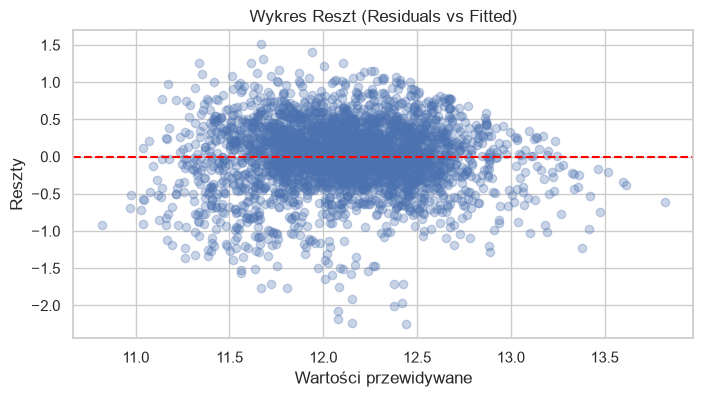

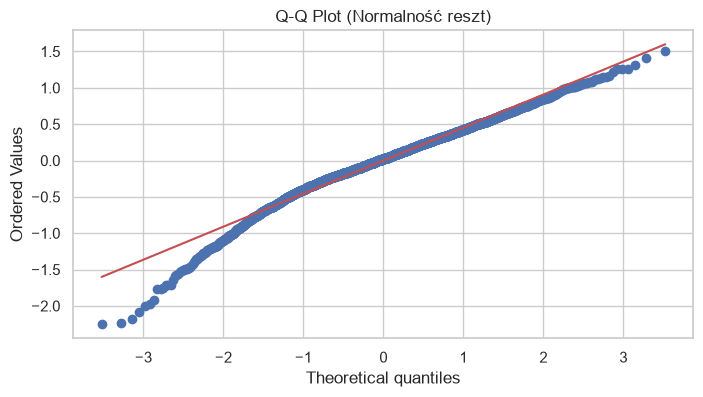

In [ ]:


X = df_final.drop(['Cena_Log'], axis=1)
y = df_final['Cena_Log']


X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()



print(model_sm.pvalues.sort_values())
print("\n(Jeśli P>|t| < 0.05, zmienna jest istotna statystycznie)\n")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

print(f"R-squared: {r2:.3f}")
print(f"Średni błąd (RMSE) w Euro: {rmse:.2f} €")

nazwa_pliku_modelu = 'lr_model_mieszkania.pkl'  
joblib.dump(model, nazwa_pliku_modelu)
print(f"Model został zapisany jako: {nazwa_pliku_modelu}")



coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Waga'])
print("\nWagi zmiennych:")
print(coeffs.sort_values(by='Waga', ascending=False))


reszty = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, reszty, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres Reszt (Residuals vs Fitted)')
plt.xlabel('Wartości przewidywane')
plt.ylabel('Reszty')
plt.show()


plt.figure(figsize=(8, 4))
stats.probplot(reszty, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normalność reszt)')
plt.show()




Zbudowany model regresji liniowej charakteryzuje się wysoką istotnością statystyczną wszystkich przyjętych zmiennych objaśniających. Model wyjaśnia 43% zmienności cen nieruchomości, co przy dużej heterogeniczności zbioru danych (od mieszkań w małych miejscowościach po luksusowe nieruchomości w metropoliach) należy uznać za wynik zadowalający. Analiza wag potwierdziła intuicje rynkowe, wskazując na kluczowe znaczenie lokalizacji oraz udogodnień takich jak bliskość morza czy modernizacja techniczna lokalu. Wykres reszt nie wykazuje wyraźnych, nieliniowych wzorców (jest heteroskedatyczność, ale nie jest ogromna - wynika z dużej rozpiętości cenowej rynku nieruchomości). 
Analiza Q-Q Plot wskazuje na zbliżony do normalnego rozkład reszt modelu. Drobne odchylenia na końcach wykresu sugerują występowanie wartości ekstremalnych (outliers) w segmencie bardzo tanich oraz bardzo drogich nieruchomości, których model nie wyjaśnia w pełni.

Teraz regresja dla domów:

In [64]:
df_final_domy = df_domy_encoded.drop(['Prowincja', 'Kod_Prowincji', 'Cena', 'Tytul', 'URL', 'Klasa_Energetyczna', 'Typ_Dom'], axis=1)

df_final_domy['Cena_Log'] = np.log1p(df_domy_czyste['Cena'])

print(df_final.info())

<class 'pandas.DataFrame'>
Index: 16267 entries, 1 to 35738
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Metraz                        16267 non-null  int64  
 1   Liczba_Pokoi                  16267 non-null  int64  
 2   Blisko_Morza                  16267 non-null  int64  
 3   Po_Remoncie                   16267 non-null  int64  
 4   Winda                         16267 non-null  int64  
 5   Klimatyzacja                  16267 non-null  int64  
 6   Dlugosc_Opisu                 16267 non-null  int64  
 7   Region_Basilicata             16267 non-null  int64  
 8   Region_Calabria               16267 non-null  int64  
 9   Region_Campania               16267 non-null  int64  
 10  Region_Emilia-Romagna         16267 non-null  int64  
 11  Region_Friuli-Venezia Giulia  16267 non-null  int64  
 12  Region_Lazio                  16267 non-null  int64  
 13  Region_Liguria   

In [65]:
X_vif_domy = df_final_domy.drop(['Cena_Log'], axis=1)

vif_data_domy = pd.DataFrame()
vif_data_domy["feature"] = X_vif_domy.columns
vif_data_domy["VIF"] = [variance_inflation_factor(X_vif_domy.values, i) for i in range(len(X_vif_domy.columns))]

print(vif_data_domy.sort_values(by="VIF", ascending=False))

                         feature        VIF
7              Prowincja_Encoded  22.906418
1                   Liczba_Pokoi  10.972794
0                         Metraz   6.595106
6                  Dlugosc_Opisu   6.359522
26                 Region_Veneto   4.544552
15              Region_Lombardia   4.367075
11         Region_Emilia-Romagna   4.064745
21                Region_Sicilia   3.920965
13                  Region_Lazio   3.295323
22                Region_Toscana   3.071225
20               Region_Sardegna   2.468544
18               Region_Piemonte   2.427740
10               Region_Campania   2.069790
12  Region_Friuli-Venezia Giulia   2.030560
19                 Region_Puglia   1.984845
16                 Region_Marche   1.544525
14                Region_Liguria   1.501828
2                   Blisko_Morza   1.358850
24                 Region_Umbria   1.356236
23    Region_Trentino-Alto Adige   1.309127
9                Region_Calabria   1.201833
17                 Region_Molise

const                            0.000000e+00
Metraz                          6.177735e-185
Prowincja_Encoded               5.162830e-146
Dlugosc_Opisu                    4.490523e-45
Blisko_Morza                     2.330400e-30
Liczba_Pokoi                     3.136951e-19
Klimatyzacja                     4.559410e-10
Region_Toscana                   1.145674e-06
Winda                            4.265976e-06
Region_Lombardia                 9.399478e-05
Region_Emilia-Romagna            2.516489e-03
Region_Umbria                    2.728965e-03
Region_Friuli-Venezia Giulia     6.659051e-03
Region_Puglia                    7.368129e-03
Region_Piemonte                  8.676500e-03
Region_Valle d'Aosta             2.511639e-02
Region_Basilicata                9.012650e-02
Region_Lazio                     1.077772e-01
Region_Sardegna                  1.113531e-01
Region_Liguria                   2.331764e-01
Po_Remoncie                      2.925645e-01
Region_Campania                  2

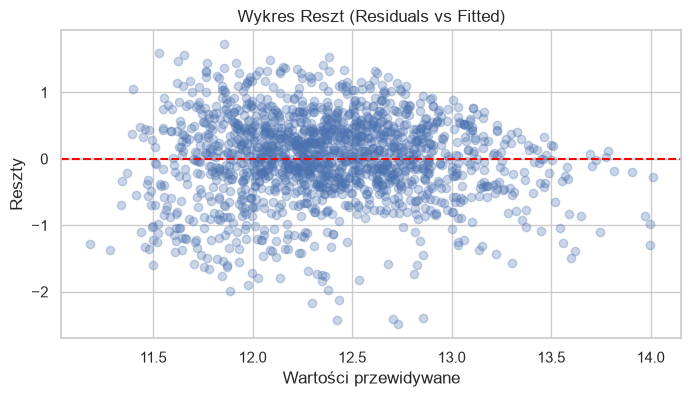

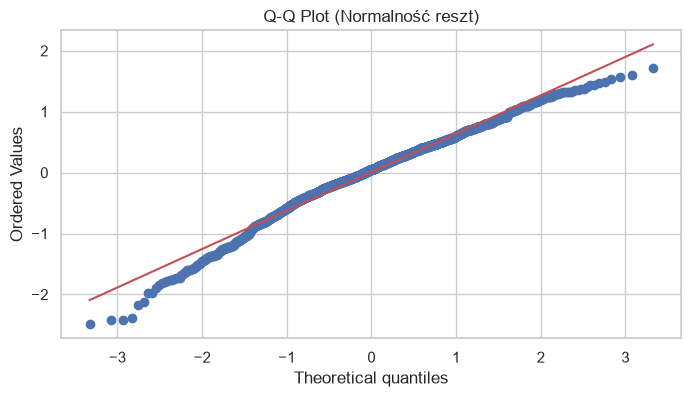

In [ ]:
X = df_final_domy.drop(['Cena_Log'], axis=1)
y = df_final_domy['Cena_Log']


X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()


print(model_sm.pvalues.sort_values())
print("\n(Jeśli P>|t| < 0.05, zmienna jest istotna statystycznie)\n")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

print(f"R-squared: {r2:.3f}")
print(f"Średni błąd (RMSE) w Euro: {rmse:.2f} €")

nazwa_pliku_modelu = 'lr_model_domy.pkl'  
joblib.dump(model, nazwa_pliku_modelu)
print(f"Model został zapisany jako: {nazwa_pliku_modelu}")

coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Waga'])
print("\nWagi zmiennych:")
print(coeffs.sort_values(by='Waga', ascending=False))


reszty = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, reszty, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Wykres Reszt (Residuals vs Fitted)')
plt.xlabel('Wartości przewidywane')
plt.ylabel('Reszty')
plt.show()

# C. Q-Q Plot
plt.figure(figsize=(8, 4))
stats.probplot(reszty, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normalność reszt)')
plt.show()



Trenowanie Lasu Losowego dla MIESZKAŃ...

--- WYNIKI RANDOM FOREST (MIESZKANIA) ---
R-squared: 0.437
RMSE: 96769.92 €

Najważniejsze zmienne dla mieszkań:
                         Zmienna   Ważność
7              Prowincja_Encoded  0.322270
0                         Metraz  0.253542
6                  Dlugosc_Opisu  0.220558
1                   Liczba_Pokoi  0.058280
2                   Blisko_Morza  0.021627
4                          Winda  0.019662
3                    Po_Remoncie  0.018486
5                   Klimatyzacja  0.011104
15              Region_Lombardia  0.007665
10               Region_Campania  0.007209
13                  Region_Lazio  0.006997
21                Region_Sicilia  0.006745
20               Region_Sardegna  0.006261
14                Region_Liguria  0.005249
11         Region_Emilia-Romagna  0.004789
22                Region_Toscana  0.004509
26                 Region_Veneto  0.004401
19                 Region_Puglia  0.004004
18               Region_Piem

/var/folders/0j/_dqxrtcn5k70c82kvn0httph0000gn/T/ipykernel_97979/2667773274.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Zmienna', data=importances, palette='mako')


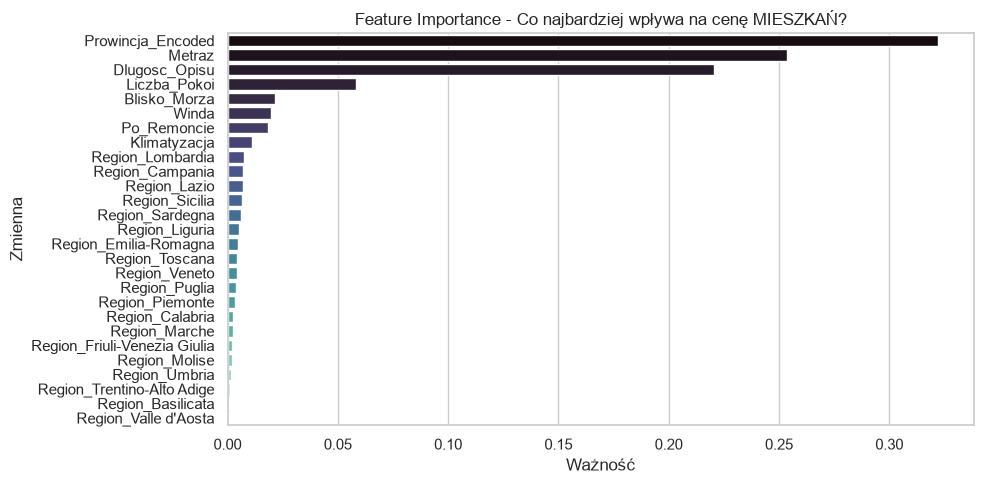

Zapisano pliki: lr_model_mieszkania.pkl, rf_model_mieszkania.pkl



In [ ]:

X_mieszkania = df_final.drop(['Cena_Log'], axis=1)
y_mieszkania = df_final['Cena_Log']

X_train, X_test, y_train, y_test = train_test_split(X_mieszkania, y_mieszkania, test_size=0.2, random_state=42)


lr_mieszkania = LinearRegression()
lr_mieszkania.fit(X_train, y_train)



rf_mieszkania = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_mieszkania.fit(X_train, y_train)

y_pred_rf = rf_mieszkania.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf)))


print(f"R-squared: {r2_rf:.3f}")
print(f"RMSE: {rmse_rf:.2f} €")


importances = pd.DataFrame({
    'Zmienna': X_mieszkania.columns,
    'Ważność': rf_mieszkania.feature_importances_
}).sort_values(by='Ważność', ascending=False)

print("\nNajważniejsze zmienne dla mieszkań:")
print(importances)

plt.figure(figsize=(10, 5))
sns.barplot(x='Ważność', y='Zmienna', data=importances, palette='mako')
plt.title('Feature Importance - Co najbardziej wpływa na cenę MIESZKAŃ?')
plt.tight_layout()
plt.show()

joblib.dump(lr_mieszkania, 'lr_model_mieszkania.pkl')
joblib.dump(rf_mieszkania, 'rf_model_mieszkania.pkl')
print("Zapisano pliki: lr_model_mieszkania.pkl, rf_model_mieszkania.pkl\n")

Trenowanie Lasu Losowego dla DOMÓW...

--- WYNIKI RANDOM FOREST (DOMY) ---
R-squared: 0.337
RMSE: 186924.33 €

Najważniejsze zmienne dla domów:
                         Zmienna   Ważność
0                         Metraz  0.357611
7              Prowincja_Encoded  0.226330
6                  Dlugosc_Opisu  0.204311
1                   Liczba_Pokoi  0.072989
2                   Blisko_Morza  0.026196
3                    Po_Remoncie  0.009918
21                Region_Sicilia  0.008841
22                Region_Toscana  0.008790
5                   Klimatyzacja  0.008620
20               Region_Sardegna  0.008118
15              Region_Lombardia  0.007911
26                 Region_Veneto  0.007551
10               Region_Campania  0.007022
13                  Region_Lazio  0.006417
11         Region_Emilia-Romagna  0.005876
12  Region_Friuli-Venezia Giulia  0.005789
18               Region_Piemonte  0.005407
19                 Region_Puglia  0.004845
16                 Region_Marche  0.003

/var/folders/0j/_dqxrtcn5k70c82kvn0httph0000gn/T/ipykernel_97979/3540689817.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Zmienna', data=importances, palette='flare')


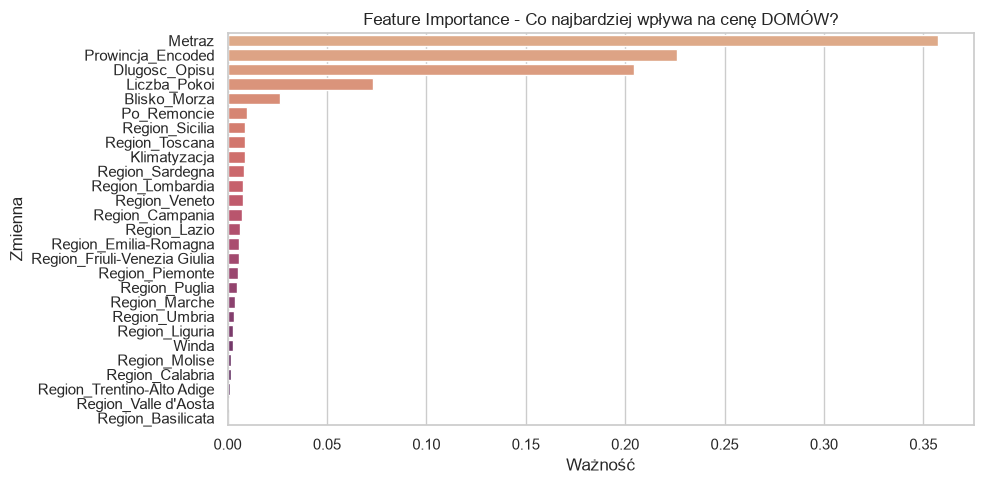

Zapisano pliki: lr_model_domy.pkl, rf_model_domy.pkl



In [ ]:

X_domy = df_final_domy.drop(['Cena_Log'], axis=1)
y_domy = df_final_domy['Cena_Log']

X_train, X_test, y_train, y_test = train_test_split(X_domy, y_domy, test_size=0.2, random_state=42)


lr_domy = LinearRegression()
lr_domy.fit(X_train, y_train)


print("Trenowanie Lasu Losowego dla DOMÓW...")
rf_domy = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_domy.fit(X_train, y_train)

y_pred_rf = rf_domy.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf)))


print(f"R-squared: {r2_rf:.3f}")
print(f"RMSE: {rmse_rf:.2f} €")


importances = pd.DataFrame({
    'Zmienna': X_domy.columns,
    'Ważność': rf_domy.feature_importances_
}).sort_values(by='Ważność', ascending=False)

print("\nNajważniejsze zmienne dla domów:")
print(importances)


plt.figure(figsize=(10, 5))
sns.barplot(x='Ważność', y='Zmienna', data=importances, palette='flare')
plt.title('Feature Importance - Co najbardziej wpływa na cenę DOMÓW?')
plt.tight_layout()
plt.show()


joblib.dump(lr_domy, 'lr_model_domy.pkl')
joblib.dump(rf_domy, 'rf_model_domy.pkl')
print("Zapisano pliki: lr_model_domy.pkl, rf_model_domy.pkl\n")

In [ ]:

# 1. Enkoder dla mieszkań
srednie_ceny_mieszkania = df_mieszkania_czyste.groupby('Kod_Prowincji')['Cena'].mean()
encoder_mieszkania = np.log1p(srednie_ceny_mieszkania).to_dict()

# 2. Enkoder dla domów
srednie_ceny_domy = df_domy_czyste.groupby('Kod_Prowincji')['Cena'].mean()
encoder_domy = np.log1p(srednie_ceny_domy).to_dict()

# 3. Zapis do plików
joblib.dump(encoder_mieszkania, 'encoder_mieszkania.pkl')
joblib.dump(encoder_domy, 'encoder_domy.pkl')

print("Pliki enkoderów zostały poprawnie wygenerowane!")

Pliki enkoderów zostały poprawnie wygenerowane!
